Categorical plots: https://seaborn.pydata.org/tutorial/categorical.html

V-Measure paper (with definition of F-Measure): https://www.aclweb.org/anthology/D07-1043.pdf

In [1]:
import json

from matplotlib.backends.backend_pdf import PdfPages
from weasyprint import HTML

from utils.analysis import align_clusterings_for_sklearn
from utils.io import load_clustering, get_review_pmids
from utils.metrics import pd_score
from utils.preprocessing import preprocess_clustering, get_clustering_level

In [2]:
RESULTS_JSON = '/home/willenjoy/work/pubtrends/local/nature_reviews/grid_search/full_2021_03_03/grid_search_full_2021-03-03_13_22.json'

In [3]:
with open(RESULTS_JSON, 'r') as f:
    results = json.load(f)

In [4]:
ground_truth = {}

for pmid in get_review_pmids():
    clustering = load_clustering(pmid)
    for level in range(1, get_clustering_level(clustering)):
        ground_truth[(pmid, level)] = preprocess_clustering(clustering, max_level=level,
                                                            include_box_sections=False,
                                                            uniqueness_method='unique_only')

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="ticks", color_codes=True)

In [6]:
PARAM_NAMES = ['bibcoupling', 'cocitation', 'citation', 'text_citation']

In [7]:
score_data = []
partitions = {}

for paper in results:
    pmid = paper['pmid']
    level = paper['level']
    full_id = f'{pmid} ({level})'
    grid_results = paper['results']
    for result in grid_results:
        soi = result['soi']
        data = result['results']
        partition = data['partition']
        score = data['v_measure_score']
        
        max_soi = max(soi)
        main_param_idx = soi.index(max_soi)
        main_param = PARAM_NAMES[main_param_idx]
        n_clusters = len(set(partition.values()))
        
        labels_true, labels_pred = align_clusterings_for_sklearn(ground_truth[(pmid, level)], partition)
        
        score_data.append((pmid, level, *soi, 
                           score, pd_score(labels_true, labels_pred), 
                           n_clusters, main_param, full_id))
        partitions[(pmid, level, *soi)] = partition

In [8]:
score_df = pd.DataFrame(score_data, columns=['PMID', 'Level', *PARAM_NAMES, 
                                             'V-Score', 'PD-Score',
                                             'Clusters', 'Largest Parameter', 'PMID (level)'])

In [19]:
score_df.head(5)

,PMID,Level,bibcoupling,cocitation,citation,text_citation,V-Score,PD-Score,Clusters,Largest Parameter,PMID (level),V-0.01*C
0,26580716,1,0.0,1,0.0,0.0000,0.360186,0.217836,7,cocitation,26580716 (1),0.290186
1,26580716,1,0.0,1,0.0,0.0625,0.359994,0.216823,7,cocitation,26580716 (1),0.289994
2,26580716,1,0.0,1,0.0,0.1250,0.359994,0.216823,7,cocitation,26580716 (1),0.289994
3,26580716,1,0.0,1,0.0,0.2500,0.361698,0.218405,7,cocitation,26580716 (1),0.291698
4,26580716,1,0.0,1,0.0,0.5000,0.361280,0.229159,7,cocitation,26580716 (1),0.291280


In [10]:
def get_top_parameter_sets(target_col, n=5):
    return score_df.groupby(PARAM_NAMES)[target_col].mean().sort_values(ascending=False).head(n).reset_index()

In [11]:
def get_best_clustering(score_df, target_col, unique=False):
    cols_to_select = ['PMID', 'Level', *PARAM_NAMES, target_col, 'Clusters']
    idx = score_df.groupby('PMID (level)')[target_col].transform(max) == score_df[target_col]
    if unique:
        return score_df.loc[idx, cols_to_select].drop_duplicates(subset=['PMID', 'Level'])
    return score_df.loc[idx, cols_to_select]

In [12]:
def plot_catplot(score_df, target_col, filename):
    g = sns.catplot(x=target_col, y="PMID (level)", hue="Largest Parameter", 
                    kind="strip", data=score_df, height=40, aspect=0.5)
    g.savefig(filename)

In [13]:
def add_reg_column(score_df, reg):
    reg_column = f'V-{reg}*C'
    score_df[reg_column] = score_df['V-Score'] - reg * score_df['Clusters']
    return score_df, reg_column

In [14]:
def plot_contingency_matrix(cm, title_str):
    fig = plt.figure(figsize = (10,7))
    sns.heatmap(cm, annot=True)
    plt.title(title_str)
    plt.xlabel('PubTrends')
    plt.ylabel('Nature Reviews')
    return fig

In [15]:
def print_dataframe_to_pdf(df, filename):
    table = df.to_html(classes='mystyle', index=False)

    html_string = f'''
    <html>
      <head><title>HTML Pandas Dataframe with CSS</title></head>
      <link rel="stylesheet" type="text/css" href="df_style.css"/>
      <body>
        {table}
      </body>
    </html>
    '''

    HTML(string=html_string).write_pdf(filename, stylesheets=["df_style.css"])

In [21]:
score_cols = ['PD-Score']

In [18]:
reg = 0.01
score_df, reg_column = add_reg_column(score_df, reg=reg)

In [23]:
score_cols.append(reg_column)

In [ ]:
for col in score_cols:
    print(get_top_parameter_sets(col))

In [195]:
best_clustering_df = get_best_clustering(score_df, reg_column, unique=True)

In [196]:
print_dataframe_to_pdf(best_clustering_df, f'best_clustering_stats_V_score-{reg}*Clusters.pdf')

In [197]:
with PdfPages(f'best_clusterings_V_score-{reg}*Clusters.pdf') as pdf:
    for index, row in best_clustering_df.iterrows():
        p_key = (row['PMID'], row['Level'], 
                 row['bibcoupling'], row['cocitation'], row['citation'], row['text_citation'])
        gt_key = (row['PMID'], row['Level'])
        partition = partitions[p_key]
        gt = ground_truth[gt_key]
        labels_true, labels_pred = align_clusterings_for_sklearn(partition, gt)
        contingency = contingency_matrix(labels_true, labels_pred)
        
        title_str = f"{row['PMID']} - LEVEL {row['Level']}\nReg-Score: {row[reg_column]}"
        fig = plot_contingency_matrix(contingency, title_str)
        pdf.savefig(fig)
        plt.close()
        
        print('.', end='')

.......................................................................................

In [ ]:
plot_catplot(score_df, reg_column, f'full_grid_search_V_score-{reg}*Clusters.png')

## Plot Mean Score Changes for Different Sets of Parameters

In [62]:
import matplotlib.pyplot as plt

def plot_param_grid(param_grid_array, ax, vmin, vmax, param_range, row_label, col_label, title):
    im = ax.imshow(param_grid_array, vmin=vmin, vmax=vmax, cmap="viridis")
    
    # We want to show all ticks...
    n_params = len(param_range)
    ax.set_xticks(np.arange(n_params))
    ax.set_yticks(np.arange(n_params))
    # ... and label them with the respective list entries
    ax.set_xticklabels(param_range)
    ax.set_yticklabels(param_range)
    ax.set_xlabel(col_label)
    ax.set_ylabel(row_label)
    ax.set_title(title, fontweight='bold')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    for i in range(n_params):
        for j in range(n_params):
            display_value = round(param_grid_array[i, j], 2)
            text = ax.text(j, i, display_value,
                           ha="center", va="center", color="w")

In [68]:
# TARGET_COLUMN = 'PD-Score'
TARGET_COLUMN = reg_column

In [69]:
mean_score_df = score_df.groupby(PARAM_NAMES)[TARGET_COLUMN].mean().reset_index()

In [70]:
with_cocitation = mean_score_df.cocitation == 1
print(mean_score_df[with_cocitation].groupby(['bibcoupling'])[TARGET_COLUMN].mean())

bibcoupling
0.0000     0.273213
0.0625     0.274556
0.1250     0.275617
0.2500     0.277082
0.5000     0.279993
1.0000     0.278855
2.0000     0.264864
4.0000     0.245958
8.0000     0.229297
16.0000    0.220649
Name: V-0.01*C, dtype: float64


In [71]:
param_range = [0, 0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8, 16]
param_idx = {param: i for i, param in enumerate(param_range)}

n_params = len(param_range)
param_grid_array = np.zeros((n_params, n_params))  

In [77]:
# Min should be at least 0, negative values are the least important, but mess up the color scheme
vmin = max(mean_score_df[TARGET_COLUMN].min(), 0)
vmax = mean_score_df[TARGET_COLUMN].max()
print(vmin, vmax)

0 0.3150143130716808


In [73]:
cocitations = [1] * n_params + [0] * 2
bibcoupling = param_range + [1, 0]
slice_params = list(zip(cocitations, bibcoupling))

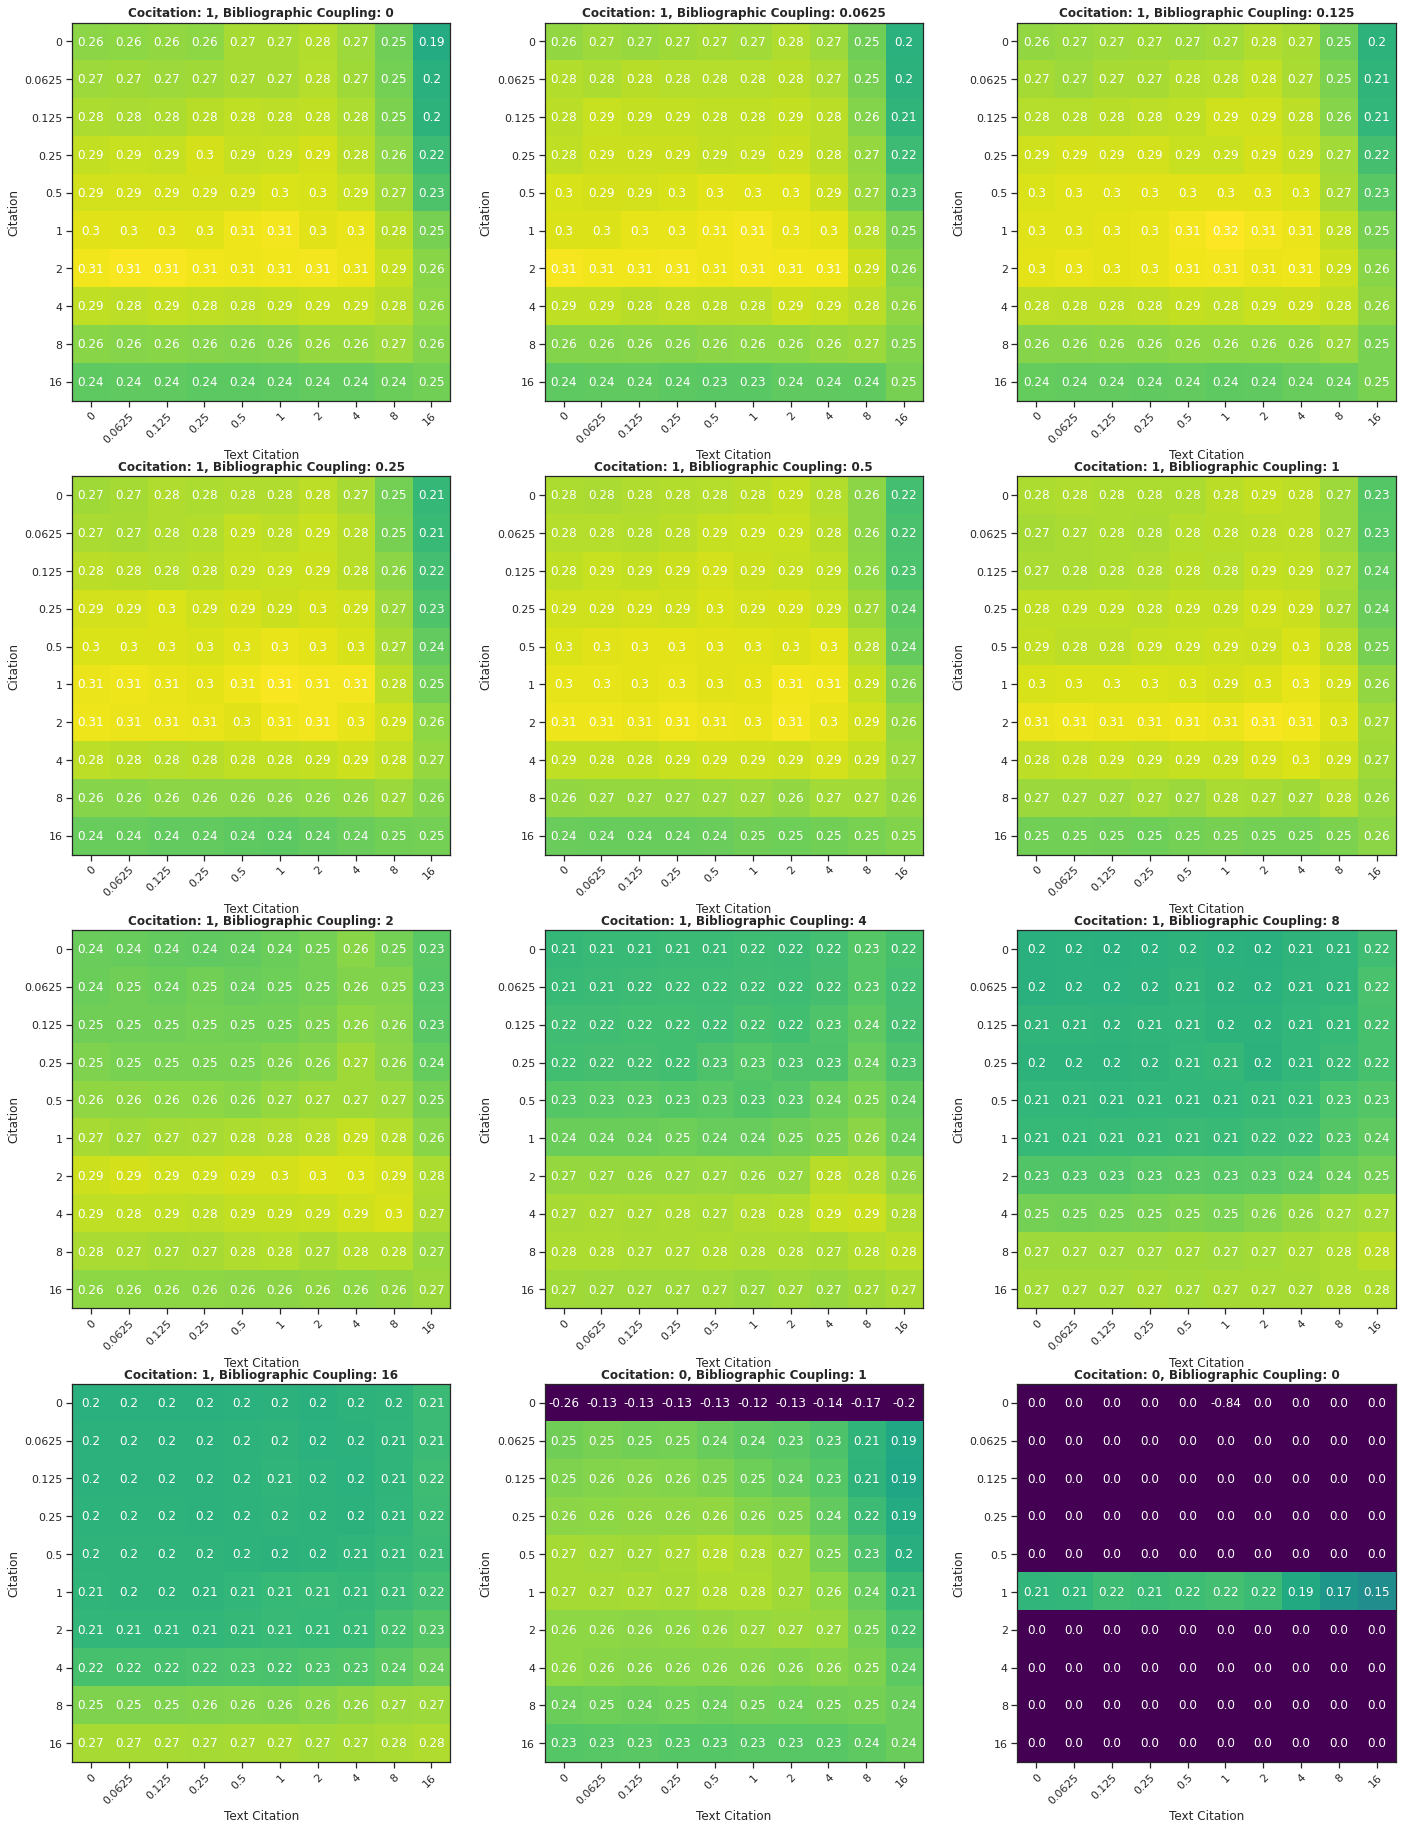

In [76]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9), (ax10, ax11, ax12)) = plt.subplots(4, 3, figsize=(24, 32))

for (cc, bc), ax in zip(slice_params, 
                        [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12]):
    df_part = mean_score_df[np.logical_and(mean_score_df.cocitation == cc, 
                                           mean_score_df.bibcoupling == bc)]
    
    param_grid_array = np.zeros((n_params, n_params))  
    for index, row in df_part.iterrows():
        citation = row.citation
        text_citation = row.text_citation
        param_grid_array[param_idx[citation], param_idx[text_citation]] = row[TARGET_COLUMN]
        
    plot_param_grid(param_grid_array, ax, 
                    vmin, vmax,
                    param_range, 
                    'Citation', 'Text Citation',
                    f'Cocitation: {cc}, Bibliographic Coupling: {bc}')

## Generate Dummy Results to Test Visualizations

In [5]:
import random
import itertools

from utils.io import get_review_pmids

random.seed(20210302)

In [4]:
PARAM_RANGE = [0, 1, 2]
PARAM_NAMES = ['SIMILARITY_COCITATION',
               'SIMILARITY_BIBLIOGRAPHIC_COUPLING',
               'SIMILARITY_CITATION',
               'SIMILARITY_TEXT_CITATION']
PARAM_GRID = {p: PARAM_RANGE for p in PARAM_NAMES}

In [19]:
def generate_grid_results():
    grid_results = []
    min_value = random.uniform(0.1, 0.3)
    max_value = min_value + random.uniform(0.2, 0.4)
    for param_values in itertools.product(*PARAM_GRID.values()):
        if sum(param_values) == 0:
            continue
        grid_results.append({
            'soi': list(param_values),
            'results': {
                'v_measure_score': random.uniform(min_value, max_value)
            }
        })
    return grid_results

def generate_dummy_results(n_reviews):
    results = []
    for pmid in get_review_pmids()[:n_reviews]:
        results.append({
            'pmid': pmid,
            'level': 1,
            'results': generate_grid_results()
        })
    return results

In [40]:
results = generate_dummy_results(40)